Dataset Created Successfully
Dataset Shape: (300, 11)
  Hotel_Type  Room_Occupancy  AC_Usage_Hours  Lighting_Load_kW  \
0   Business             167               4         29.171548   
1     Resort             210              10         82.161988   
2     Resort             112               7         72.414717   
3     Resort              73               9         78.192730   
4     Resort             276               8        102.238414   

   Kitchen_Power_kW  Elevator_Usage  Laundry_Load  Outdoor_Temperature  \
0         42.498126              14            65                   32   
1        131.350209              49           111                   34   
2         64.885744              18            67                   22   
3         59.780551              11            53                   31   
4        107.516026              83            80                   37   

  Solar_Panel_Usage Peak_Hour Energy_Status  
0                No        No        Normal  
1           

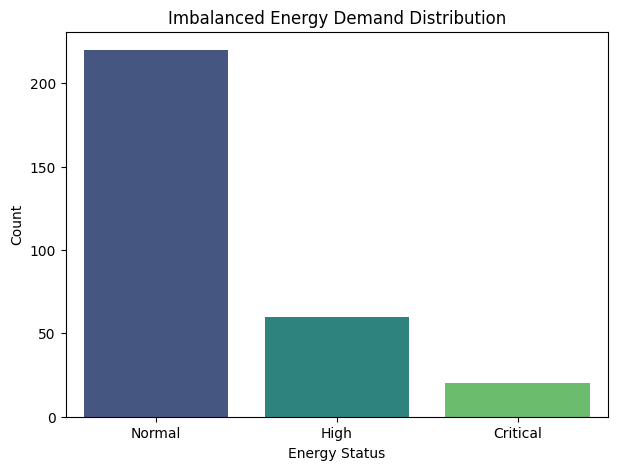

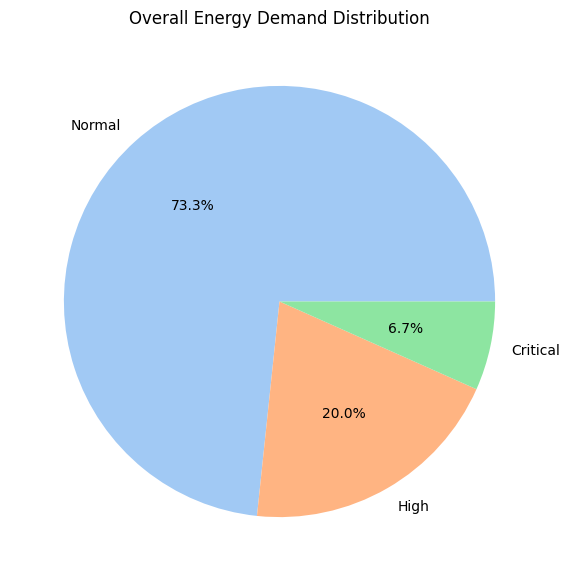

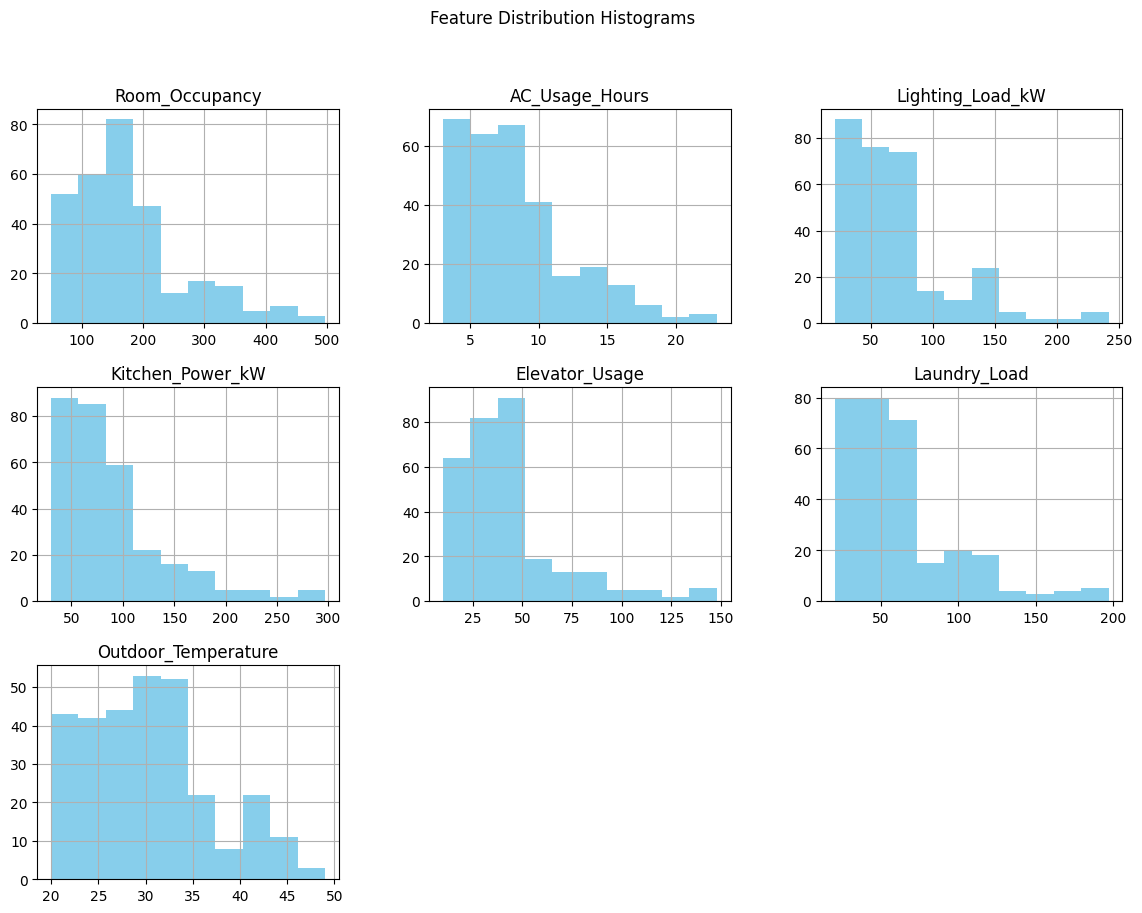

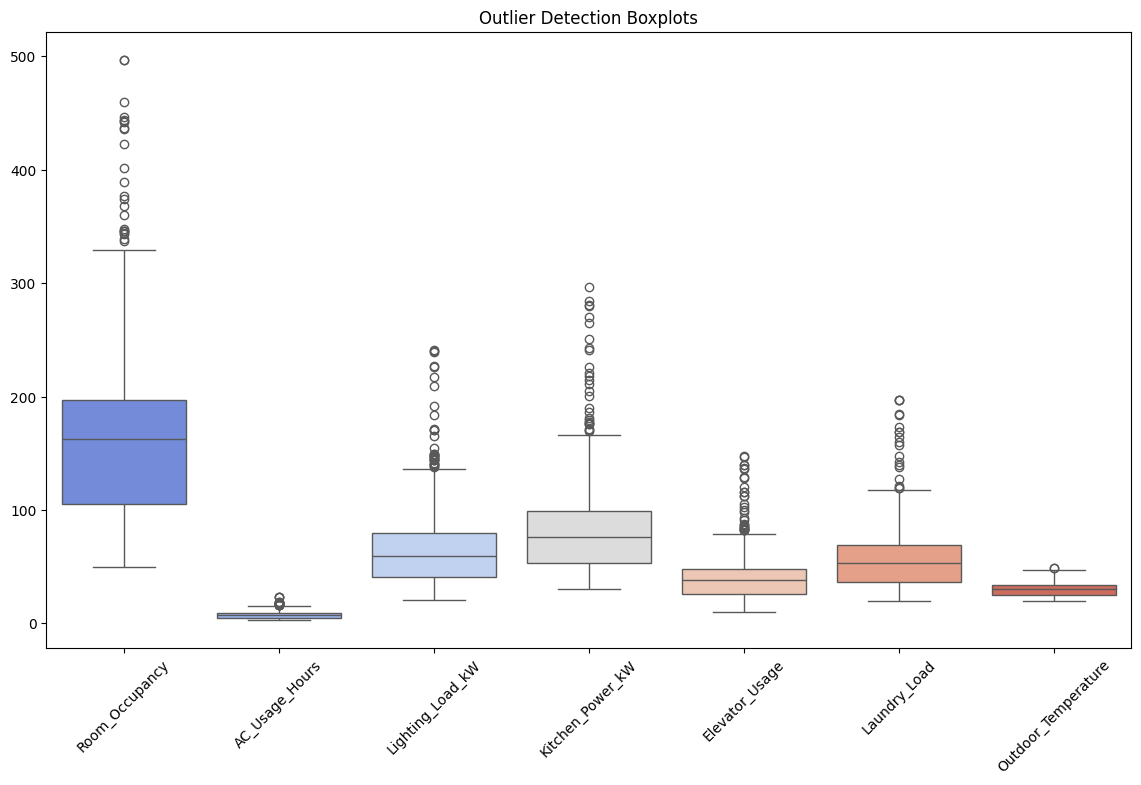

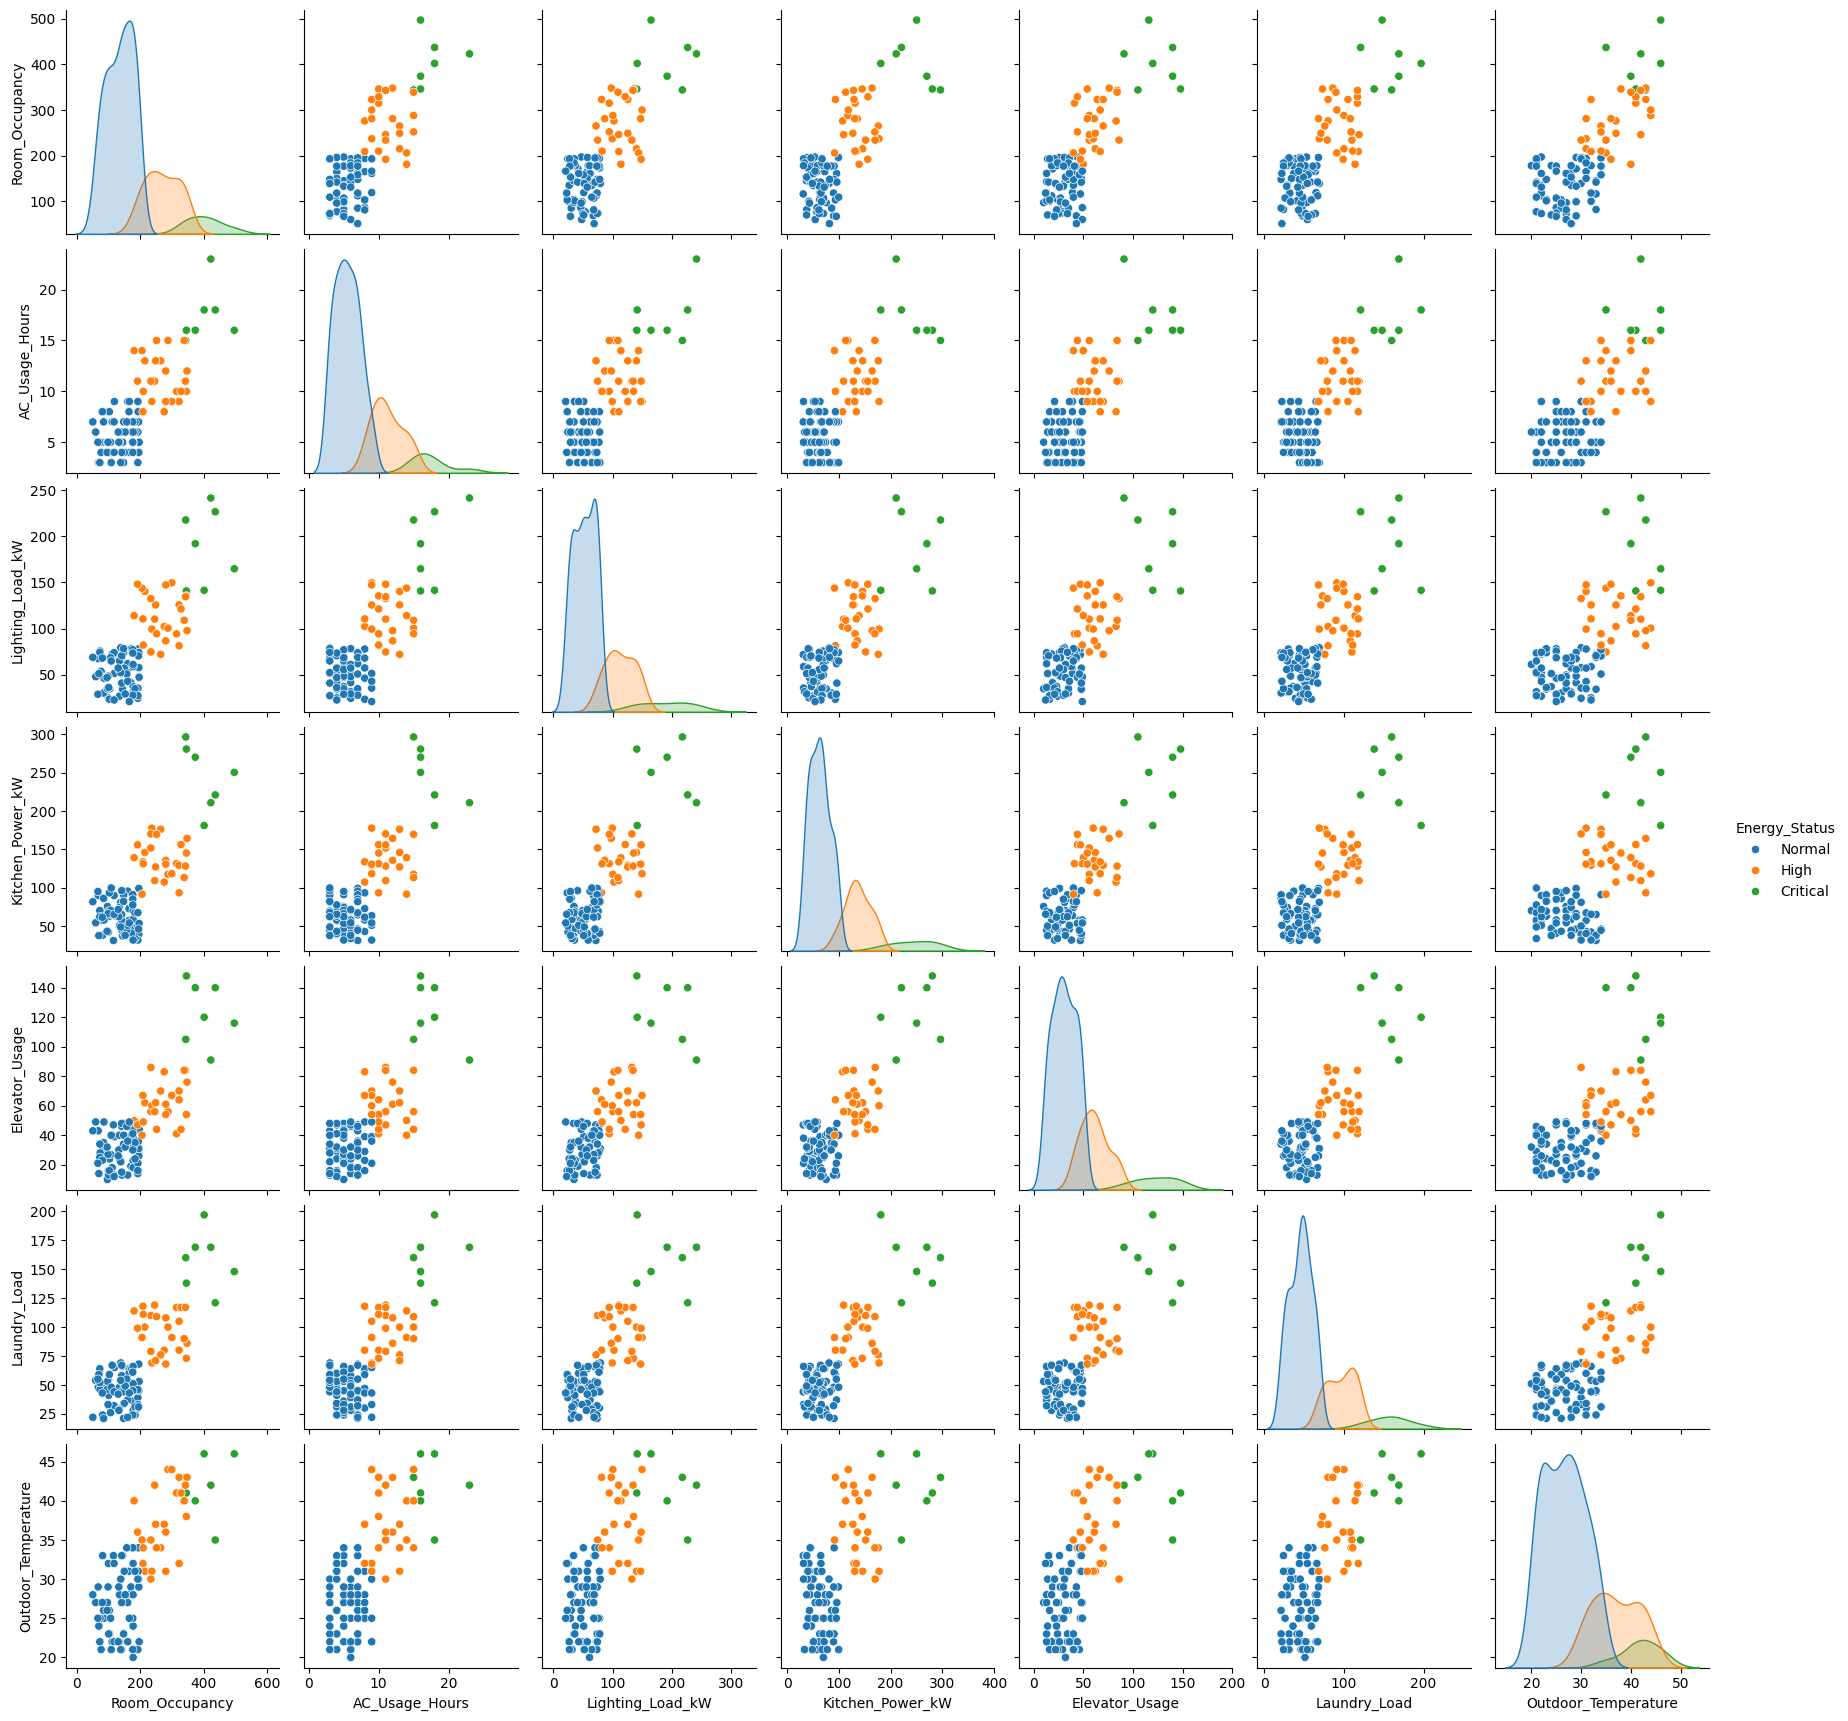

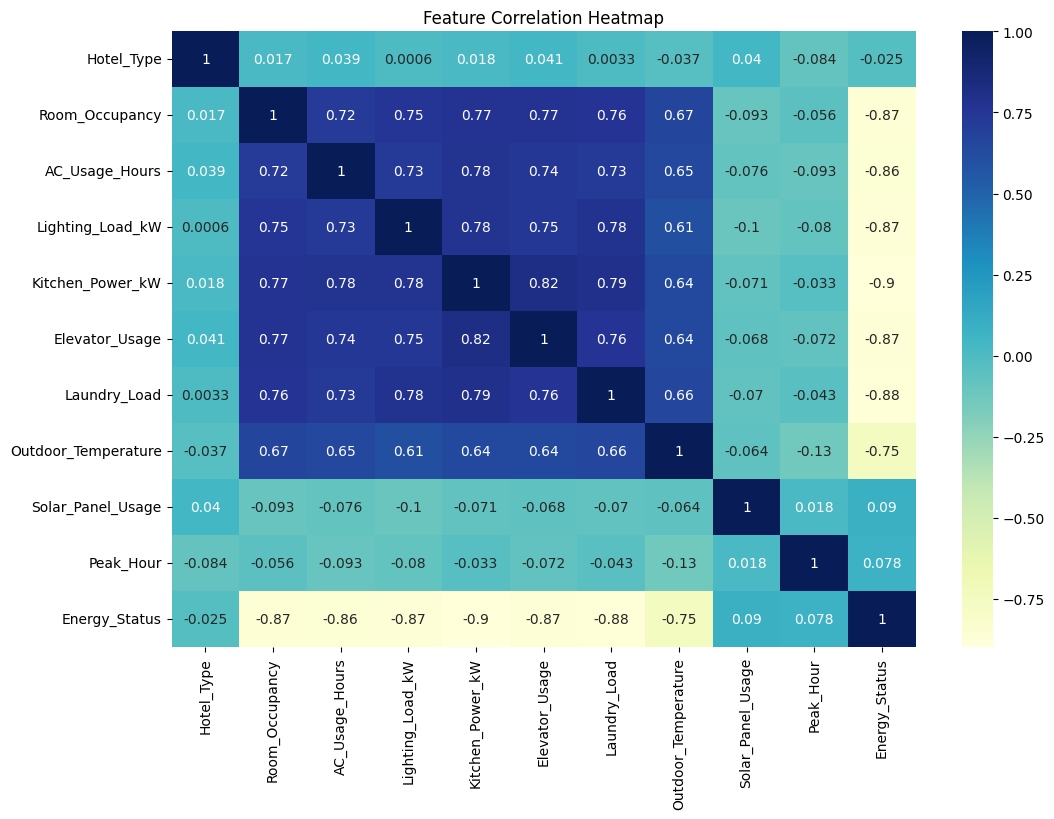

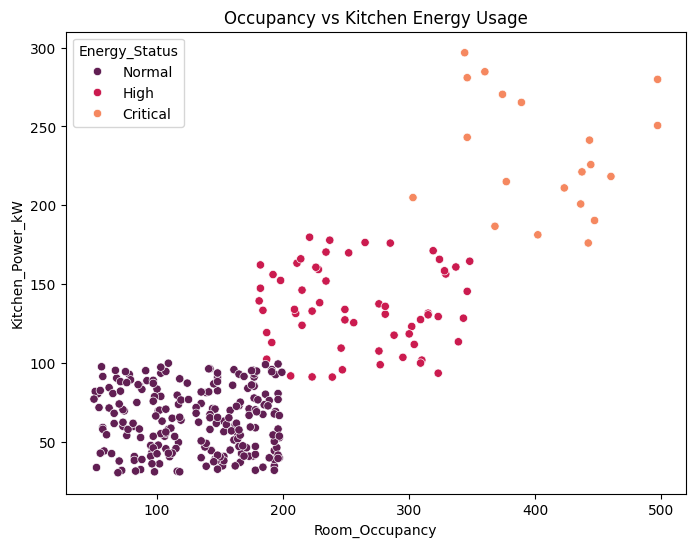

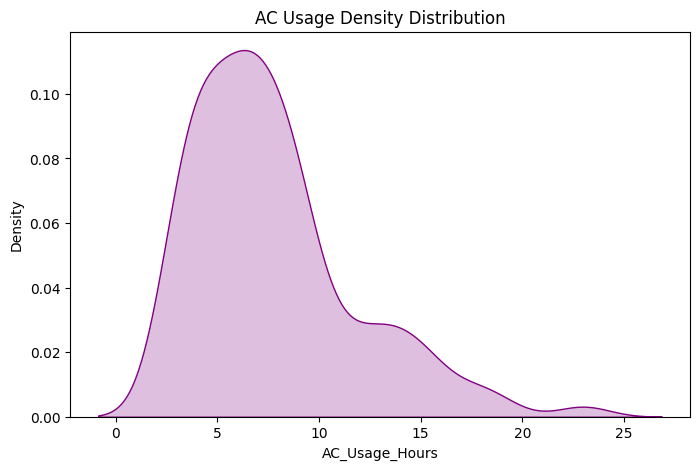

   Hotel_Type  Room_Occupancy  AC_Usage_Hours  Lighting_Load_kW  \
0           0             167               4         29.171548   
1           2             210              10         82.161988   
2           2             112               7         72.414717   
3           2              73               9         78.192730   
4           2             276               8        102.238414   

   Kitchen_Power_kW  Elevator_Usage  Laundry_Load  Outdoor_Temperature  \
0         42.498126              14            65                   32   
1        131.350209              49           111                   34   
2         64.885744              18            67                   22   
3         59.780551              11            53                   31   
4        107.516026              83            80                   37   

   Solar_Panel_Usage  Peak_Hour  Energy_Status  
0                  0          0              2  
1                  1          1              1  
2    

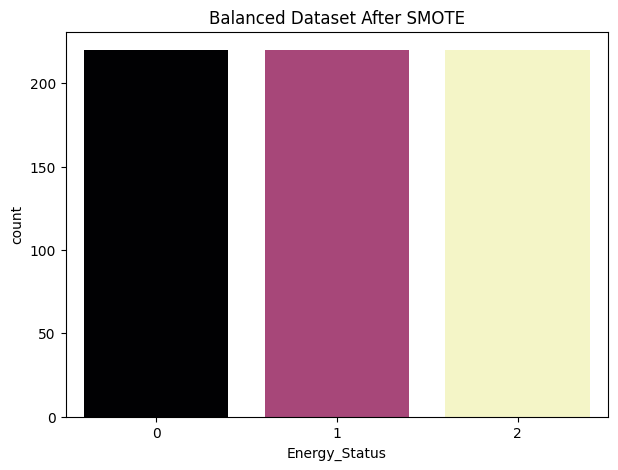

Training Shape: (528, 10)
Testing Shape: (132, 10)
Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 1.0
XGBoost Accuracy: 0.9924242424242424
Precision: 0.992609016999261
Recall: 0.9924242424242424
F1 Score: 0.9924349313238203


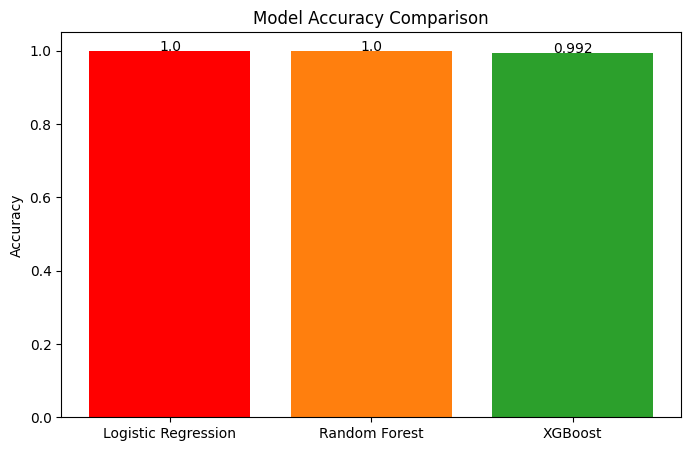

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       0.98      1.00      0.99        40
           2       1.00      0.98      0.99        53

    accuracy                           0.99       132
   macro avg       0.99      0.99      0.99       132
weighted avg       0.99      0.99      0.99       132



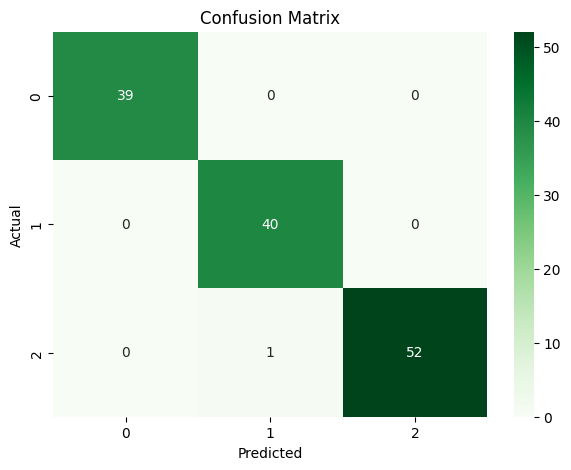

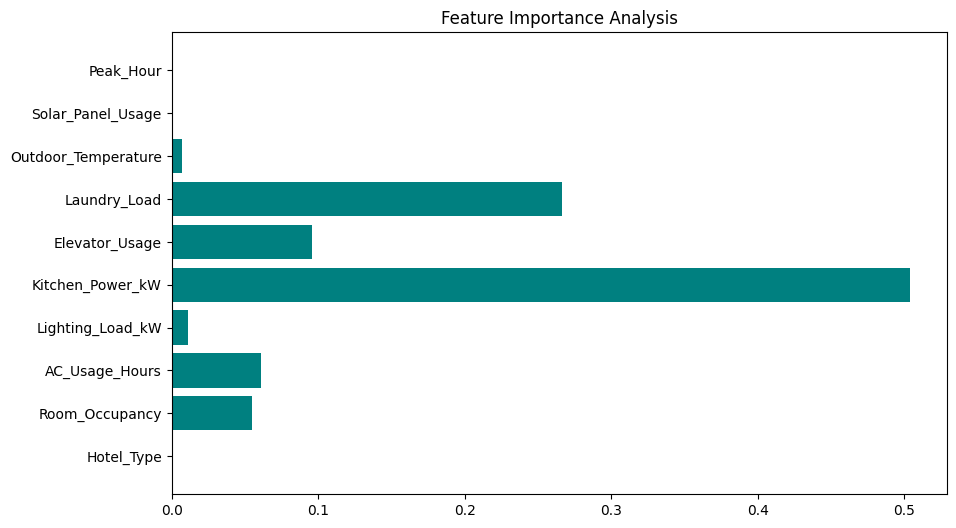

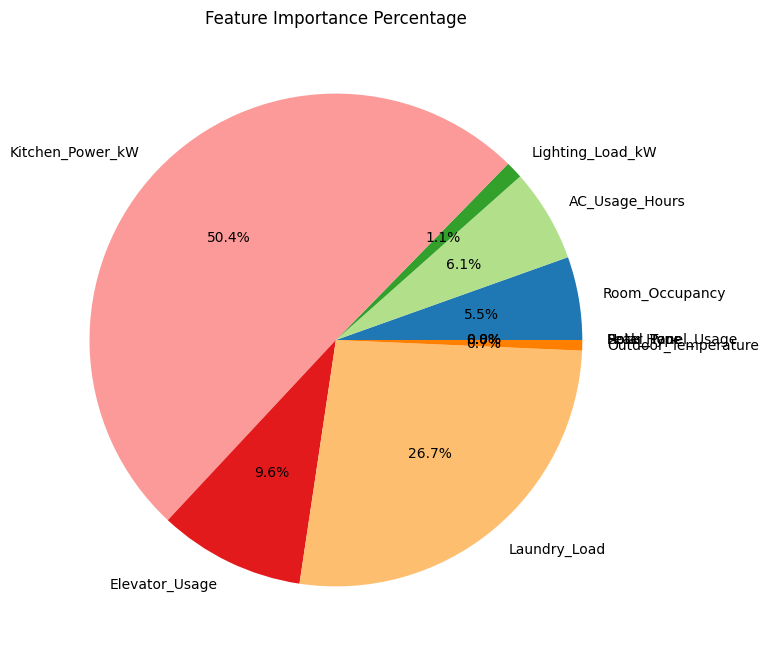

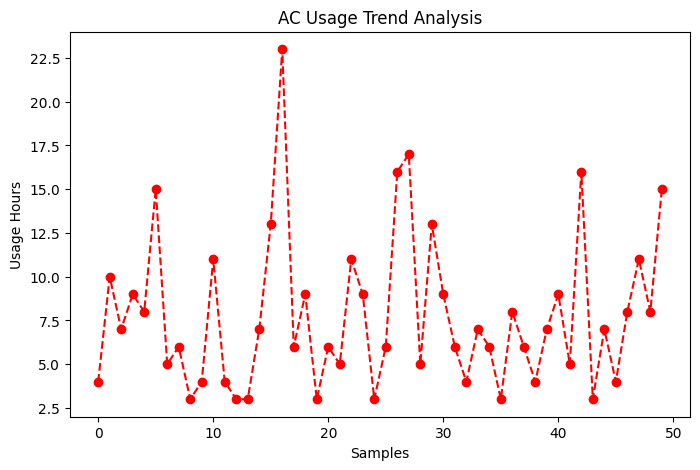

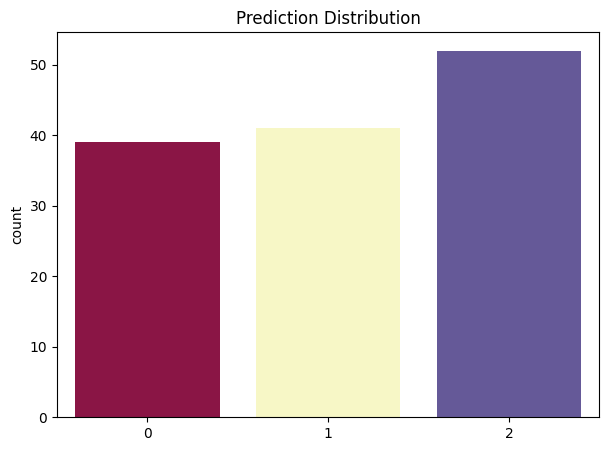

Model Saved Successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Prediction: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE

import joblib

# =========================================================
# STEP 3 — CREATE IMBALANCED DATASET
# =========================================================

np.random.seed(42)

# ---------------- NORMAL ----------------

normal = pd.DataFrame({
    'Hotel_Type': np.random.choice(['Luxury', 'Business', 'Resort'], 220),
    'Room_Occupancy': np.random.randint(50, 200, 220),
    'AC_Usage_Hours': np.random.randint(3, 10, 220),
    'Lighting_Load_kW': np.random.uniform(20, 80, 220),
    'Kitchen_Power_kW': np.random.uniform(30, 100, 220),
    'Elevator_Usage': np.random.randint(10, 50, 220),
    'Laundry_Load': np.random.randint(20, 70, 220),
    'Outdoor_Temperature': np.random.randint(20, 35, 220),
    'Solar_Panel_Usage': np.random.choice(['Yes', 'No'], 220),
    'Peak_Hour': np.random.choice(['Yes', 'No'], 220),
    'Energy_Status': 'Normal'
})

# ---------------- HIGH ----------------

high = pd.DataFrame({
    'Hotel_Type': np.random.choice(['Luxury', 'Business', 'Resort'], 60),
    'Room_Occupancy': np.random.randint(180, 350, 60),
    'AC_Usage_Hours': np.random.randint(8, 16, 60),
    'Lighting_Load_kW': np.random.uniform(70, 150, 60),
    'Kitchen_Power_kW': np.random.uniform(90, 180, 60),
    'Elevator_Usage': np.random.randint(40, 90, 60),
    'Laundry_Load': np.random.randint(60, 120, 60),
    'Outdoor_Temperature': np.random.randint(30, 45, 60),
    'Solar_Panel_Usage': np.random.choice(['Yes', 'No'], 60),
    'Peak_Hour': np.random.choice(['Yes', 'No'], 60),
    'Energy_Status': 'High'
})

# ---------------- CRITICAL ----------------

critical = pd.DataFrame({
    'Hotel_Type': np.random.choice(['Luxury', 'Business', 'Resort'], 20),
    'Room_Occupancy': np.random.randint(300, 500, 20),
    'AC_Usage_Hours': np.random.randint(14, 24, 20),
    'Lighting_Load_kW': np.random.uniform(140, 250, 20),
    'Kitchen_Power_kW': np.random.uniform(170, 300, 20),
    'Elevator_Usage': np.random.randint(80, 150, 20),
    'Laundry_Load': np.random.randint(100, 200, 20),
    'Outdoor_Temperature': np.random.randint(35, 50, 20),
    'Solar_Panel_Usage': np.random.choice(['Yes', 'No'], 20),
    'Peak_Hour': np.random.choice(['Yes', 'No'], 20),
    'Energy_Status': 'Critical'
})

# =========================================================
# STEP 4 — COMBINE DATASET
# =========================================================

df = pd.concat([normal, high, critical], ignore_index=True)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save Dataset

df.to_csv("hotel_energy_dataset.csv", index=False)

print("Dataset Created Successfully")
print("Dataset Shape:", df.shape)

# =========================================================
# STEP 5 — LOAD DATASET
# =========================================================

df = pd.read_csv("hotel_energy_dataset.csv")

print(df.head())

# =========================================================
# STEP 6 — DATASET INFORMATION
# =========================================================

print(df.info())

# =========================================================
# STEP 7 — STATISTICAL SUMMARY (EDA)
# =========================================================

print(df.describe())

# =========================================================
# STEP 8 — MISSING VALUES CHECK
# =========================================================

print(df.isnull().sum())

# =========================================================
# STEP 9 — CLASS DISTRIBUTION GRAPH
# PURPOSE:
# SHOWS IMBALANCED DATASET
# =========================================================

plt.figure(figsize=(7,5))

sns.countplot(x='Energy_Status', data=df, hue='Energy_Status', palette='viridis', legend=False) # Fixed FutureWarning

plt.title("Imbalanced Energy Demand Distribution")

plt.xlabel("Energy Status")

plt.ylabel("Count")

plt.show()

# =========================================================
# STEP 10 — PIE CHART
# PURPOSE:
# SHOWS OVERALL DEMAND DISTRIBUTION
# =========================================================

energy_counts = df['Energy_Status'].value_counts()

plt.figure(figsize=(7,7))

colors = sns.color_palette('pastel')[0:len(energy_counts)] # Define colors
plt.pie(
    energy_counts,
    labels=energy_counts.index,
    autopct='%1.1f%%',
    colors=colors # Added colors
)

plt.title("Overall Energy Demand Distribution")

plt.show()

# =========================================================
# STEP 11 — HISTOGRAMS
# PURPOSE:
# SHOWS FEATURE DISTRIBUTIONS
# =========================================================

df.hist(figsize=(14,10), color='skyblue') # Added color

plt.suptitle("Feature Distribution Histograms")

plt.show()

# =========================================================
# STEP 12 — BOXPLOTS
# PURPOSE:
# DETECTS OUTLIERS
# =========================================================

plt.figure(figsize=(14,8))

sns.boxplot(data=df.select_dtypes(include=np.number), palette='coolwarm') # Added palette

plt.xticks(rotation=45)

plt.title("Outlier Detection Boxplots")

plt.show()

# =========================================================
# STEP 13 — PAIRPLOT
# PURPOSE:
# SHOWS FEATURE RELATIONSHIPS
# =========================================================

sample_pairplot = df.sample(100)

sns.pairplot(
    sample_pairplot,
    hue='Energy_Status',
    palette='tab10' # Added palette
)

plt.show()

# =========================================================
# STEP 14 — HEATMAP
# PURPOSE:
# SHOWS FEATURE CORRELATION
# =========================================================

heatmap_df = df.copy()

encoder = LabelEncoder()

for col in heatmap_df.columns:
    if heatmap_df[col].dtype == 'object':
        heatmap_df[col] = encoder.fit_transform(heatmap_df[col])

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_df.corr(),
    annot=True,
    cmap='YlGnBu' # Changed cmap
)

plt.title("Feature Correlation Heatmap")

plt.show()

# =========================================================
# STEP 15 — SCATTER PLOT
# PURPOSE:
# OCCUPANCY VS ENERGY USAGE
# =========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Room_Occupancy'],
    y=df['Kitchen_Power_kW'],
    hue=df['Energy_Status'],
    palette='rocket' # Added palette
)

plt.title("Occupancy vs Kitchen Energy Usage")

plt.show()

# =========================================================
# STEP 16 — KDE PLOT
# PURPOSE:
# SHOWS AC USAGE DENSITY
# =========================================================

plt.figure(figsize=(8,5))

sns.kdeplot(df['AC_Usage_Hours'], fill=True, color='purple') # Added color

plt.title("AC Usage Density Distribution")

plt.show()

# =========================================================
# STEP 17 — ENCODE CATEGORICAL DATA
# =========================================================

encoder = LabelEncoder()

categorical_cols = [
    'Hotel_Type',
    'Solar_Panel_Usage',
    'Peak_Hour',
    'Energy_Status'
]

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

# =========================================================
# STEP 18 — FEATURES & TARGET
# =========================================================

X = df.drop('Energy_Status', axis=1)

y = df['Energy_Status']

# =========================================================
# STEP 19 — BALANCE DATASET USING SMOTE
# PURPOSE:
# FIXES IMBALANCED DATASET
# =========================================================

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Original Shape:", X.shape)

print("Balanced Shape:", X_resampled.shape)

# =========================================================
# STEP 20 — BALANCED DATASET GRAPH
# =========================================================

plt.figure(figsize=(7,5))

sns.countplot(x=y_resampled, hue=y_resampled, palette='magma', legend=False) # Fixed FutureWarning

plt.title("Balanced Dataset After SMOTE")

plt.show()

# =========================================================
# STEP 21 — TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

# =========================================================
# STEP 22 — FEATURE SCALING
# PURPOSE:
# NORMALIZES DATA
# =========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# =========================================================
# STEP 23 — LOGISTIC REGRESSION
# =========================================================

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_acc = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_acc)

# =========================================================
# STEP 24 — RANDOM FOREST
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

# =========================================================
# STEP 25 — XGBOOST
# =========================================================

xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)



# =========================================================
# STEP 26 — PERFORMANCE METRICS
# =========================================================

precision = precision_score(
    y_test,
    xgb_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    xgb_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    xgb_pred,
    average='weighted'
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# =========================================================
# STEP 27 — ACCURACY COMPARISON CHART
# PURPOSE:
# COMPARES MODEL PERFORMANCE
# =========================================================

models = [
    'Logistic Regression',
    'Random Forest',
    'XGBoost'
]

accuracies = [
    log_acc,
    rf_acc,
    xgb_acc
]

plt.figure(figsize=(8,5))

# Determine the model with the highest accuracy
max_accuracy_index = np.argmax(accuracies)

# Define colors for bars, highlighting the best one
bar_colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Default colors
highlight_color = 'red' # Color for the best model

# Apply highlight color to the best model
colors_with_highlight = [bar_colors[i] if i != max_accuracy_index else highlight_color for i in range(len(models))]

bars = plt.bar(models, accuracies, color=colors_with_highlight) # Use colors with highlight

for bar in bars:
    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        round(yval, 3),
        ha='center'
    )

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

# =========================================================
# STEP 28 — CLASSIFICATION REPORT
# =========================================================

print(classification_report(y_test, xgb_pred))

# =========================================================
# STEP 29 — CONFUSION MATRIX
# PURPOSE:
# SHOWS PREDICTION PERFORMANCE
# =========================================================

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens' # Changed cmap
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# =========================================================
# STEP 30 — FEATURE IMPORTANCE
# PURPOSE:
# SHOWS MOST IMPORTANT FEATURES
# =========================================================

importance = xgb_model.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))

plt.barh(features, importance, color='teal') # Added color

plt.title("Feature Importance Analysis")

plt.show()

# =========================================================
# STEP 31 — FEATURE IMPORTANCE PIE CHART
# =========================================================

plt.figure(figsize=(8,8))

colors = sns.color_palette('Paired') # Define colors
plt.pie(
    importance,
    labels=features,
    autopct='%1.1f%%',
    colors=colors # Added colors
)

plt.title("Feature Importance Percentage")

plt.show()

# =========================================================
# STEP 32 — ENERGY TREND GRAPH
# PURPOSE:
# SHOWS ENERGY USAGE PATTERNS
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(df['AC_Usage_Hours'][:50], color='red', marker='o', linestyle='--') # Added color, marker, linestyle

plt.title("AC Usage Trend Analysis")

plt.xlabel("Samples")

plt.ylabel("Usage Hours")

plt.show()

# =========================================================
# STEP 33 — PREDICTION DISTRIBUTION
# PURPOSE:
# SHOWS MODEL PREDICTION PATTERNS
# =========================================================

plt.figure(figsize=(7,5))

sns.countplot(x=xgb_pred, hue=xgb_pred, palette='Spectral', legend=False) # Fixed FutureWarning

plt.title("Prediction Distribution")

plt.show()

# =========================================================
# STEP 34 — SAVE MODEL
# =========================================================

joblib.dump(xgb_model, 'energysense_model.pkl')

joblib.dump(scaler, 'scaler.pkl')

print("Model Saved Successfully")

# =========================================================
# STEP 35 — DOWNLOAD FILES
# =========================================================

from google.colab import files

files.download('energysense_model.pkl')

files.download('scaler.pkl')

files.download('hotel_energy_dataset.csv')

# =========================================================
# STEP 36 — MANUAL TESTING
# =========================================================

sample = np.array([
    [1, 320, 18, 170, 240, 110, 160, 42, 1, 1]
])

sample_scaled = scaler.transform(sample)

prediction = xgb_model.predict(sample_scaled)

print("Prediction:", prediction)